<a href="https://colab.research.google.com/github/dhnchandan/ColabConnect/blob/main/tensorflow/tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

In [ ]:
tf.__version__

'2.19.0'

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss=tf.keras.losses.mae,
    metrics=['mae']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

# Generate some dummy data for training
# Assuming input shape (1,) and output shape (3,) based on your model
X_train = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]], dtype=np.float32)
y_train = np.array([[2.0, 4.0, 6.0], [4.0, 8.0, 12.0], [6.0, 12.0, 18.0], [8.0, 16.0, 24.0], [10.0, 20.0, 30.0]], dtype=np.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (5, 1)
y_train shape: (5, 3)


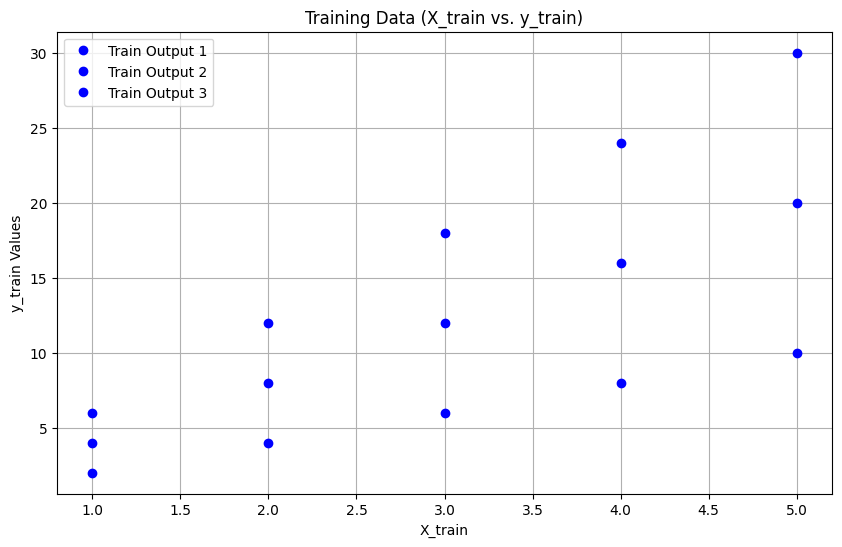

In [ ]:
import matplotlib.pyplot as plt

# Assuming y_train has shape (num_samples, num_outputs)
num_outputs = y_train.shape[1]

plt.figure(figsize=(10, 6))

for i in range(num_outputs):
    plt.plot(X_train, y_train[:, i], 'bo', label=f'Train Output {i+1}')

plt.title('Training Data (X_train vs. y_train)')
plt.xlabel('X_train')
plt.ylabel('y_train Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,  # You can adjust the number of epochs
    verbose=0 # Set to 1 for progress bar, 0 for silent
)

print("Training complete. Last epoch loss:", history.history['loss'][-1])

Training complete. Last epoch loss: 6.70342493057251


In [ ]:
model_l = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(3)
])

In [ ]:
model_l.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss=tf.keras.losses.mae,
    metrics=['mae']
)

In [ ]:
model_l.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Generate a larger dataset
num_samples = 100
X_large = np.linspace(0.0, 10.0, num_samples).reshape(-1, 1).astype(np.float32)

# Create y_large with a linear relationship and some noise, matching the model's output shape (3)
# For example, y = 2x + noise, y = 4x + noise, y = 6x + noise
y_large = np.hstack([
    (2 * X_large) + np.random.normal(0, 0.5, (num_samples, 1)),
    (4 * X_large) + np.random.normal(0, 0.5, (num_samples, 1)),
    (6 * X_large) + np.random.normal(0, 0.5, (num_samples, 1))
]).astype(np.float32)

print(f"Original X_large shape: {X_large.shape}")
print(f"Original y_large shape: {y_large.shape}")

# Split the dataset into training and testing sets
X_train_large, X_test, y_train_large, y_test = train_test_split(
    X_large, y_large, test_size=0.2, random_state=42
)

print(f"X_train_large shape: {X_train_large.shape}")
print(f"y_train_large shape: {y_train_large.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Original X_large shape: (100, 1)
Original y_large shape: (100, 3)
X_train_large shape: (80, 1)
y_train_large shape: (80, 3)
X_test shape: (20, 1)
y_test shape: (20, 3)


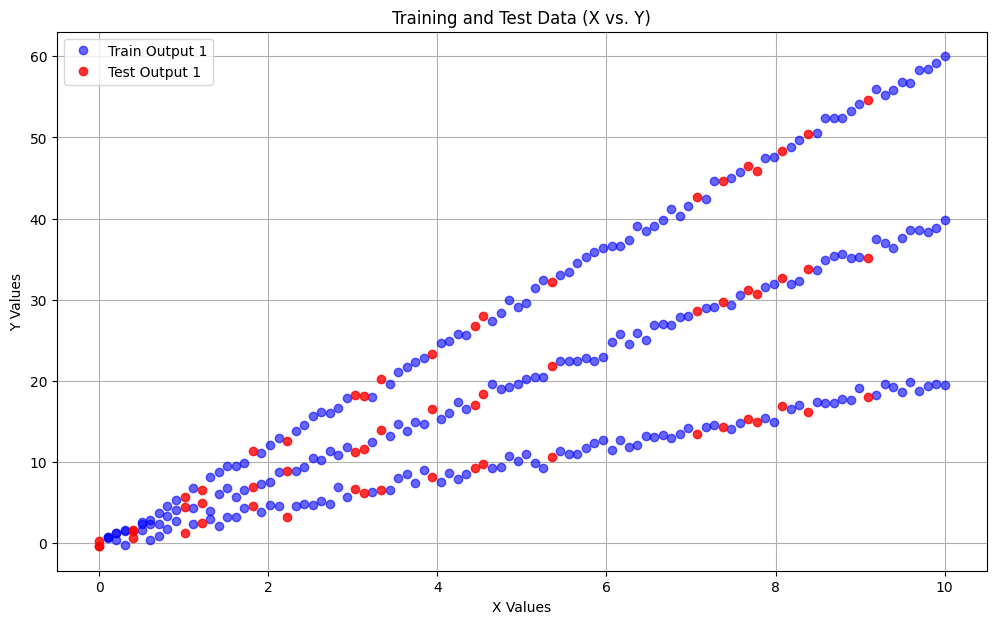

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Assuming y_train_large and y_test both have shape (num_samples, num_outputs)
num_outputs = y_train_large.shape[1]

for i in range(num_outputs):
    # Plot training data for each output dimension in blue
    plt.plot(X_train_large, y_train_large[:, i], 'bo', label=f'Train Output {i+1}' if i == 0 else "", alpha=0.6)
    # Plot test data for each output dimension in red
    plt.plot(X_test, y_test[:, i], 'ro', label=f'Test Output {i+1}' if i == 0 else "", alpha=0.8)

plt.title('Training and Test Data (X vs. Y)')
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Train the model with the larger dataset
history = model_l.fit(
    X_train_large,
    y_train_large,
    epochs=500,  # Increased epochs for larger dataset
    verbose=0 # Set to 1 for progress bar, 0 for silent
)

print("Training complete. Last epoch loss:", history.history['loss'][-1])

Training complete. Last epoch loss: 0.4351261258125305


In [ ]:
# Evaluate the model on the test data
loss, mae = model_l.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss (MAE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss (MAE): 0.4533
Test MAE: 0.4533


### Understanding the Evaluation Metrics:

*   **Loss (Mean Absolute Error - MAE)**: This is the primary metric we're optimizing during training. It represents the average magnitude of the errors in a set of predictions, without considering their direction. In simpler terms, it's the average absolute difference between the predicted values and the actual values. A lower MAE indicates a better model.

*   **MAE (Mean Absolute Error)**: This is the same as the loss function in your current model setup. It provides a direct measure of the average absolute difference between predictions and actual values.

In [ ]:
# Example of how to include MSE as a metric
# You would need to re-run model.compile() and then model.fit() again
model_l.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss=tf.keras.losses.mae, # Still optimizing for MAE
    metrics=['mae', 'mse'] # Now tracking both MAE and MSE
)

print("Model recompiled to track both MAE and MSE.")

Model recompiled to track both MAE and MSE.


After recompiling, if you were to train and evaluate the model again, the `model.evaluate()` output would include the MSE value as well.

In [ ]:
import numpy as np

# Define a new input value for prediction
new_input = np.array([[7.0]], dtype=np.float32)

# Make a prediction using the trained model
predicted_value = model_l.predict(new_input)

print(f"Input value: {new_input.flatten()[0]:.1f}")
print(f"Predicted output (y1, y2, y3): {predicted_value.flatten()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Input value: 7.0
Predicted output (y1, y2, y3): [13.895793 27.869217 41.95128 ]


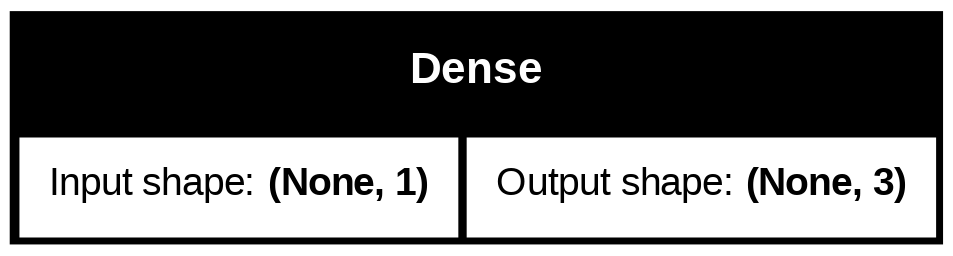

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model=model_l, show_shapes=True)

In [ ]:
y_pred = model_l.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


array([[16.62553   , 33.345936  , 50.180965  ],
       [10.648004  , 21.353125  , 32.159756  ],
       [14.035268  , 28.149048  , 42.371773  ],
       [ 9.053997  , 18.155043  , 27.354101  ],
       [ 8.854747  , 17.755283  , 26.753395  ],
       [ 7.858492  , 15.756481  , 23.749859  ],
       [ 4.471227  ,  8.960557  , 13.537841  ],
       [16.027777  , 32.146652  , 48.37884   ],
       [ 2.0802162 ,  4.1634336 ,  6.329356  ],
       [ 0.08770758,  0.16583098,  0.32228655],
       [ 3.6742234 ,  7.361516  , 11.135013  ],
       [ 6.0652337 , 12.158638  , 18.343496  ],
       [14.633021  , 29.34833   , 44.173893  ],
       [ 6.6629863 , 13.357919  , 20.145617  ],
       [18.020287  , 36.144257  , 54.385914  ],
       [ 0.8847111 ,  1.764872  ,  2.7251146 ],
       [15.230774  , 30.547611  , 45.976017  ],
       [15.430024  , 30.94737   , 46.57672   ],
       [ 2.478718  ,  4.9629545 ,  7.530771  ],
       [ 6.2644844 , 12.558398  , 18.944202  ]], dtype=float32)

In [ ]:
def plot_prediction(
        train_data=X_train_large,
        train_labels=y_train_large,
        test_data=X_test,
        test_labels=y_test,
        predictions=y_pred
):
    plt.figure(figsize=(12, 7))
    num_outputs = train_labels.shape[1]

    # Plot training data
    for i in range(num_outputs):
        plt.scatter(train_data.flatten(), train_labels[:, i], c='b', label=f'Train Data (Output {i+1})' if i == 0 else "", alpha=0.3)

    # Plot test data
    for i in range(num_outputs):
        plt.scatter(test_data.flatten(), test_labels[:, i], c='r', label=f'Test Data (Output {i+1})' if i == 0 else "", alpha=0.3)

    # Plot predictions
    for i in range(num_outputs):
        plt.scatter(test_data.flatten(), predictions[:, i], c='g', label=f'Predictions (Output {i+1})' if i == 0 else "", alpha=1.0)

    plt.title('Training, Test Data, and Predictions')
    plt.xlabel('X Values')
    plt.ylabel('Y Values')
    plt.legend()
    plt.grid(True)
    plt.show()

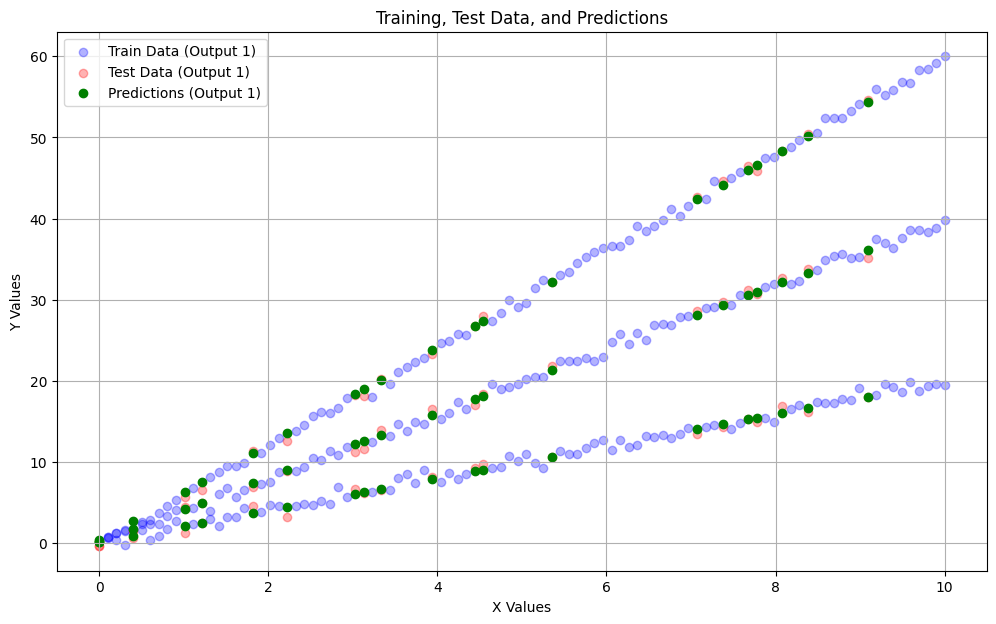

In [ ]:
plot_prediction()

In [ ]:
mae = tf.metrics.mae(y_true=y_test, y_pred=tf.squeeze(y_pred))
print(mae)
print(f"Test MAE: {tf.reduce_mean(mae).numpy():.4f}")

tf.Tensor(
[0.37795067 0.16168053 0.43126997 0.51510876 0.35913816 0.48135886
 0.7619433  0.47044626 0.5989892  0.357767   0.5246728  0.5451438
 0.36125374 0.25986037 0.40738425 0.5713437  0.4080442  0.4911197
 0.344201   0.6363931 ], shape=(20,), dtype=float32)
Test MAE: 0.4533


In [ ]:
mse = tf.metrics.mse(y_true=y_test, y_pred=tf.squeeze(y_pred))
print(mse)
print(f"Test MSE: {tf.reduce_mean(mse).numpy():.4f}")

tf.Tensor(
[0.14699823 0.06068169 0.20958245 0.31336698 0.2009653  0.27394217
 0.792339   0.34239927 0.41626897 0.15889193 0.3358948  0.38767675
 0.13254382 0.13324378 0.3483374  0.49659133 0.24333702 0.29318926
 0.29513887 0.5327686 ], shape=(20,), dtype=float32)
Test MSE: 0.3057


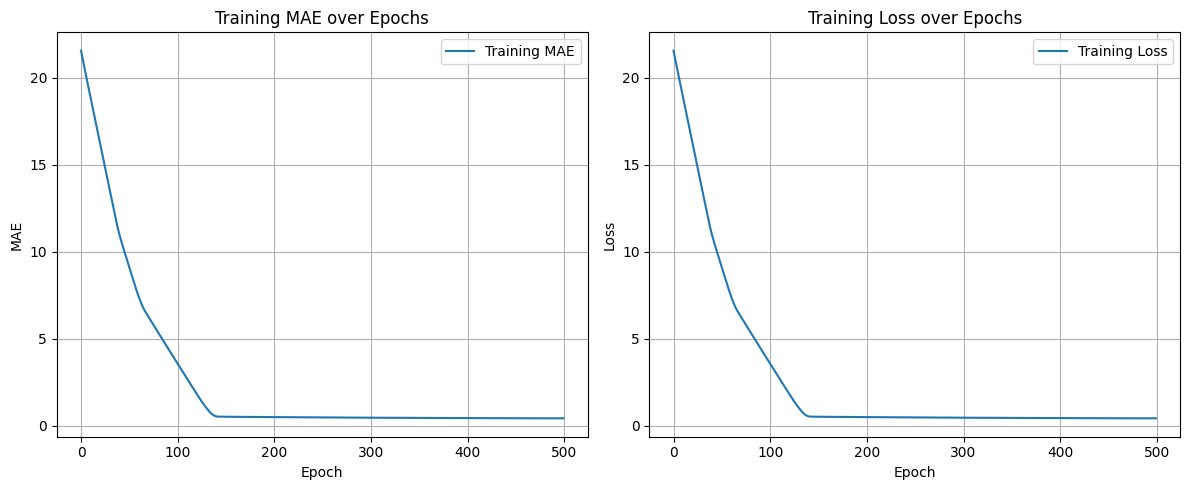

In [ ]:
import matplotlib.pyplot as plt

# Get the training history from the 'history' object
hist = history.history

# Plot training MAE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['mae'], label='Training MAE')
plt.title('Training MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

# Plot training Loss
plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()